# Coursework: Interpretable Machine Learning with Decision Tree, Random Forest, and Feed-Forward Neural Network

## Group Members

| # | Full Name | Student Number | Email | Student ID |
|---|-----------|---------------------|-------|---|
| 1 | Kigozi Allan | 2400725792 | chigozieallanie@gmail.com | 24/U/25792/PS |
| 2 | Keith Paul Kato | 2400726593 | keithpaulkato@gmail.com | 24/U/26593/EVE |
| 3 | Mugole Joel | 2400707060 | joelmugole74@gmail.com | 24/U/07060/EVE |
| 4 | Nalubega Shadiah | 2400708715 | shadiaahmed1302@gmail.com | 24/U/08715/EVE |
| 5 | Ageno Elizabeth | 2400725850 | eageno555@gmail.com | 24/U/25850/PS |

## 1. Introduction and Problem Statement

In this coursework we train three supervised regression models on a real weather dataset and interpret their predictions using two model-agnostic explanation techniques.

**Task.** Predict incoming solar radiation (W/m²) from weather measurements (precipitation, relative humidity, temperature) and station/time context (location, elevation, hour of day, month, day of year).

**Models compared.**
1. Decision Tree Regressor
2. Random Forest Regressor
3. Feed-Forward Neural Network (Multi-Layer Perceptron)

**Interpretation methods.**
1. SHAP (Shapley Additive Explanations) for global feature attribution.
2. LIME (Local Interpretable Model-agnostic Explanations) for local per-prediction attribution.

**Workflow.** Data loading, exploratory analysis, preprocessing and feature engineering, train/validation split, model training, evaluation with RMSE / MAE / R², SHAP analysis, LIME analysis, and a written comparison of the three models under both explanation methods.

## 2. Imports and Settings

In [27]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import shap
from lime.lime_tabular import LimeTabularExplainer

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 200)
sns.set_theme(style="whitegrid")

## 3. Load the Dataset

We use the `Train.csv` weather dataset. It contains 15-minute weather observations across multiple stations together with station metadata (country, elevation, latitude, longitude, installation height) and the target variable `radiation (W/m2)`.

Because the full file has hundreds of thousands of rows, we draw a **stratified random sample** so that training the neural network and computing SHAP/LIME explanations is tractable on a laptop. The sample preserves the per-station distribution.

In [28]:
DATA_DIR = Path(".")
raw_df = pd.read_csv(DATA_DIR / "Train.csv")

target_col = "radiation (W/m2)"
assert target_col in raw_df.columns, f"Expected target column '{target_col}' was not found."

print("Full dataset shape:", raw_df.shape)

# Stratified sample by station so all stations remain represented
SAMPLE_SIZE = 30000
if len(raw_df) > SAMPLE_SIZE:
    frac = SAMPLE_SIZE / len(raw_df)
    df = (
        raw_df.groupby("station", group_keys=False)
              .apply(lambda g: g.sample(frac=frac, random_state=RANDOM_STATE))
              .reset_index(drop=True)
    )
else:
    df = raw_df.copy()

print("Working sample shape:", df.shape)
df.head()

Full dataset shape: (642175, 13)
Working sample shape: (29999, 12)


,ID,timestamp,precipitation (mm),radiation (W/m2),relativehumidity (-),temperature (degrees Celsius),station_name,country,installation_height,elevation,latitude,longitude
0,b90ca874_2016-03_SDTZXO,2016-03-27 04:45:00,0.0,225.0,0.71,15.2,Nyandarua High School,KE,2.5,2427.2,-0.200178,36.376936
1,b90ca874_2016-01_6RW3AG,2016-01-14 20:15:00,0.0,0.0,0.98,13.1,Nyandarua High School,KE,2.5,2427.2,-0.200178,36.376936
2,b90ca874_2016-05_I7163I,2016-05-14 23:45:00,0.0,0.0,1.00,10.2,Nyandarua High School,KE,2.5,2427.2,-0.200178,36.376936
3,b90ca874_2016-01_EMO53D,2016-01-11 22:15:00,0.0,0.0,0.96,13.1,Nyandarua High School,KE,2.5,2427.2,-0.200178,36.376936
4,b90ca874_2016-09_WVMECT,2016-09-10 03:15:00,0.0,0.0,0.88,9.5,Nyandarua High School,KE,2.5,2427.2,-0.200178,36.376936


In [29]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 29999 entries, 0 to 29998
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   ID                             29999 non-null  str    
 1   timestamp                      29999 non-null  str    
 2   precipitation (mm)             29999 non-null  float64
 3   radiation (W/m2)               29999 non-null  float64
 4   relativehumidity (-)           29999 non-null  float64
 5   temperature (degrees Celsius)  29999 non-null  float64
 6   station_name                   29999 non-null  str    
 7   country                        29999 non-null  str    
 8   installation_height            29999 non-null  float64
 9   elevation                      29999 non-null  float64
 10  latitude                       29999 non-null  float64
 11  longitude                      29999 non-null  float64
dtypes: float64(8), str(4)
memory usage: 2.7 MB


## 4. Exploratory Data Analysis

We check missing values, the distribution of the target, and the relationship between key weather variables and radiation.

In [30]:
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
print("Missing-value percentages by column (%):")
print(missing_pct)

Missing-value percentages by column (%):
ID                               0.0
timestamp                        0.0
precipitation (mm)               0.0
radiation (W/m2)                 0.0
relativehumidity (-)             0.0
temperature (degrees Celsius)    0.0
station_name                     0.0
country                          0.0
installation_height              0.0
elevation                        0.0
latitude                         0.0
longitude                        0.0
dtype: float64


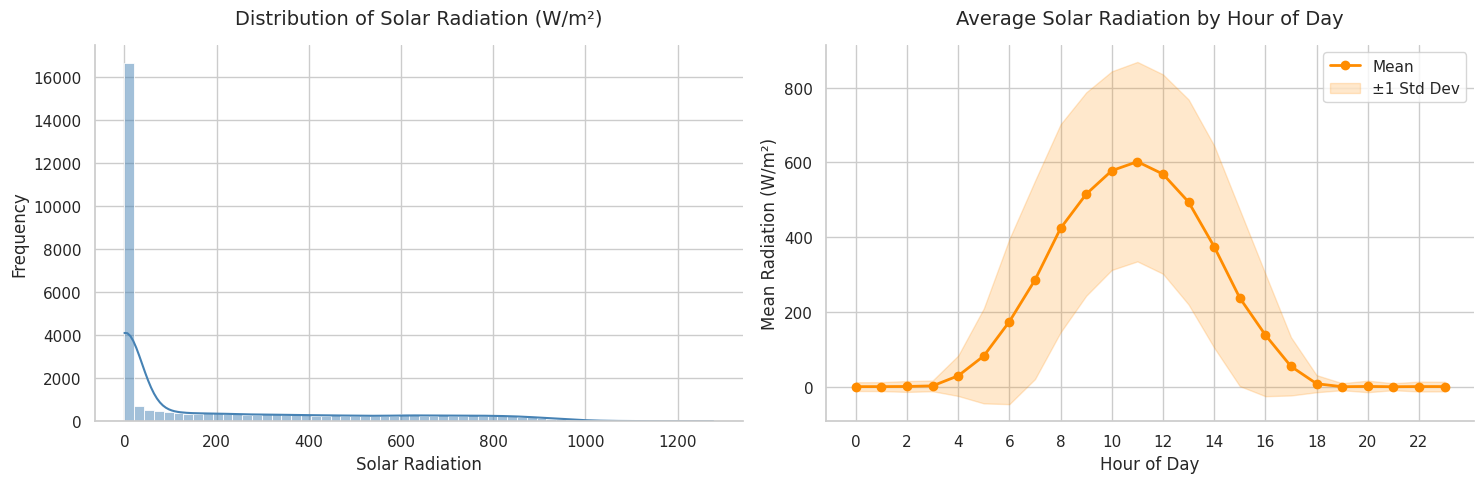

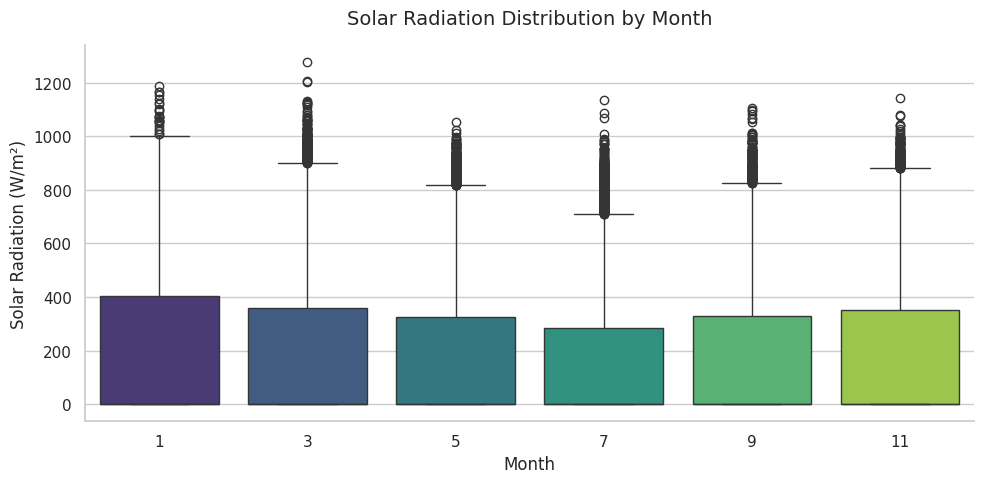

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set professional aesthetics
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'figure.figsize': (14, 6)
})

# 1. Target Distribution & Hourly Trend
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Distribution with KDE
sns.histplot(df[target_col].dropna(), bins=60, kde=True, color="steelblue", ax=axes[0])
axes[0].set_title("Distribution of Solar Radiation (W/m²)", pad=15)
axes[0].set_xlabel("Solar Radiation")
axes[0].set_ylabel("Frequency")

# Hourly Trend
df["_ts"] = pd.to_datetime(df["timestamp"], errors="coerce")
df["_hour"] = df["_ts"].dt.hour
df["_month"] = df["_ts"].dt.month

hourly_stats = df.groupby("_hour")[target_col].agg(['mean', 'std']).reset_index()
axes[1].plot(hourly_stats['_hour'], hourly_stats['mean'], marker="o", color="darkorange", linewidth=2, label="Mean")
axes[1].fill_between(hourly_stats['_hour'], 
                     hourly_stats['mean'] - hourly_stats['std'],
                     hourly_stats['mean'] + hourly_stats['std'],
                     color="darkorange", alpha=0.2, label="±1 Std Dev")

axes[1].set_title("Average Solar Radiation by Hour of Day", pad=15)
axes[1].set_xlabel("Hour of Day")
axes[1].set_ylabel("Mean Radiation (W/m²)")
axes[1].set_xticks(range(0, 24, 2))
axes[1].legend()

sns.despine()
plt.tight_layout()
plt.show()

# 2. Monthly Trend (Boxplot)
plt.figure(figsize=(10, 5))
sns.boxplot(x="_month", y=target_col, data=df, palette="viridis")
plt.title("Solar Radiation Distribution by Month", pad=15)
plt.xlabel("Month")
plt.ylabel("Solar Radiation (W/m²)")
sns.despine()
plt.tight_layout()
plt.show()


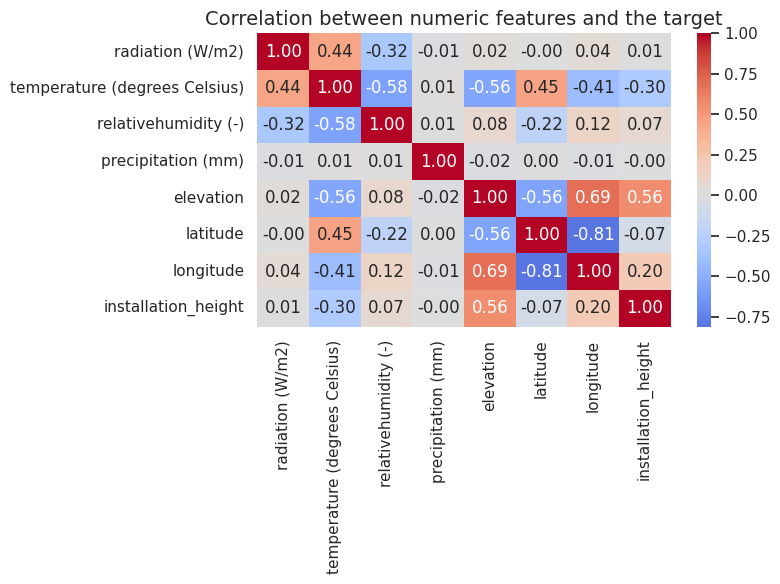

In [32]:
numeric_for_corr = [
    "radiation (W/m2)",
    "temperature (degrees Celsius)",
    "relativehumidity (-)",
    "precipitation (mm)",
    "elevation",
    "latitude",
    "longitude",
    "installation_height",
]
available = [c for c in numeric_for_corr if c in df.columns]
corr = df[available].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation between numeric features and the target")
plt.tight_layout()
plt.show()

## 5. Feature Engineering

Time-of-day and seasonality strongly drive solar radiation, so we extract calendar features and add sine/cosine encodings for cyclic variables (hour and month). These cyclic encodings let any model treat 23:00 and 00:00 as neighbouring values rather than far apart.

In [33]:
def add_time_features(frame: pd.DataFrame) -> pd.DataFrame:
    frame = frame.copy()
    ts = pd.to_datetime(frame["timestamp"], errors="coerce")
    frame["year"] = ts.dt.year
    frame["month"] = ts.dt.month
    frame["day"] = ts.dt.day
    frame["hour"] = ts.dt.hour
    frame["minute"] = ts.dt.minute
    frame["day_of_week"] = ts.dt.dayofweek
    frame["day_of_year"] = ts.dt.dayofyear
    frame["is_weekend"] = (frame["day_of_week"] >= 5).astype(int)

    frame["hour_sin"] = np.sin(2 * np.pi * frame["hour"] / 24)
    frame["hour_cos"] = np.cos(2 * np.pi * frame["hour"] / 24)
    frame["month_sin"] = np.sin(2 * np.pi * frame["month"] / 12)
    frame["month_cos"] = np.cos(2 * np.pi * frame["month"] / 12)
    frame["doy_sin"] = np.sin(2 * np.pi * frame["day_of_year"] / 365.25)
    frame["doy_cos"] = np.cos(2 * np.pi * frame["day_of_year"] / 365.25)
    return frame

model_df = add_time_features(df)
model_df = model_df.drop(columns=["_ts", "_hour"], errors="ignore")
model_df = model_df.dropna(subset=[target_col]).reset_index(drop=True)

print("Prepared dataset shape:", model_df.shape)
model_df.head()

Prepared dataset shape: (29999, 27)


,ID,timestamp,precipitation (mm),radiation (W/m2),relativehumidity (-),temperature (degrees Celsius),station_name,country,installation_height,elevation,latitude,longitude,_month,year,month,day,hour,minute,day_of_week,day_of_year,is_weekend,hour_sin,hour_cos,month_sin,month_cos,doy_sin,doy_cos
0,b90ca874_2016-03_SDTZXO,2016-03-27 04:45:00,0.0,225.0,0.71,15.2,Nyandarua High School,KE,2.5,2427.2,-0.200178,36.376936,3,2016,3,27,4,45,6,87,1,0.866025,0.500000,1.0,6.123234e-17,0.997250,0.074117
1,b90ca874_2016-01_6RW3AG,2016-01-14 20:15:00,0.0,0.0,0.98,13.1,Nyandarua High School,KE,2.5,2427.2,-0.200178,36.376936,1,2016,1,14,20,15,3,14,0,-0.866025,0.500000,0.5,8.660254e-01,0.238513,0.971139
2,b90ca874_2016-05_I7163I,2016-05-14 23:45:00,0.0,0.0,1.00,10.2,Nyandarua High School,KE,2.5,2427.2,-0.200178,36.376936,5,2016,5,14,23,45,5,135,1,-0.258819,0.965926,0.5,-8.660254e-01,0.730644,-0.682758
3,b90ca874_2016-01_EMO53D,2016-01-11 22:15:00,0.0,0.0,0.96,13.1,Nyandarua High School,KE,2.5,2427.2,-0.200178,36.376936,1,2016,1,11,22,15,0,11,0,-0.500000,0.866025,0.5,8.660254e-01,0.188099,0.982150
4,b90ca874_2016-09_WVMECT,2016-09-10 03:15:00,0.0,0.0,0.88,9.5,Nyandarua High School,KE,2.5,2427.2,-0.200178,36.376936,9,2016,9,10,3,15,5,254,1,0.707107,0.707107,-1.0,-1.836970e-16,-0.941759,-0.336289


## 6. Define Features and Train / Validation Split

We drop the row identifier, the raw timestamp (already decomposed into time features), and the target from the feature matrix. Categorical columns (station, station name, country) will be one-hot encoded inside each model's preprocessing pipeline.

In [34]:
drop_cols = [target_col, "ID", "timestamp"]
X = model_df.drop(columns=[c for c in drop_cols if c in model_df.columns])
y = model_df[target_col].astype(float)

numeric_features = X.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X.select_dtypes(exclude=["number"]).columns.tolist()

print("Total features:", X.shape[1])
print("Numeric features    :", len(numeric_features))
print("Categorical features:", len(categorical_features))
print("Numeric example     :", numeric_features[:8])
print("Categorical example :", categorical_features)

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print("Train:", X_train.shape, "| Validation:", X_valid.shape)

Total features: 24
Numeric features    : 22
Categorical features: 2
Numeric example     : ['precipitation (mm)', 'relativehumidity (-)', 'temperature (degrees Celsius)', 'installation_height', 'elevation', 'latitude', 'longitude', '_month']
Categorical example : ['station_name', 'country']
Train: (23999, 24) | Validation: (6000, 24)


## 7. Build the Three Models

Each model is wrapped in a scikit-learn `Pipeline` so preprocessing and the estimator are fitted together with no leakage between train and validation.

- Decision Tree and Random Forest use median imputation for numeric columns and one-hot encoding for categorical columns. Trees do not require feature scaling.
- The Feed-Forward Neural Network additionally standardises numeric features (`StandardScaler`), because gradient-based optimisation needs comparable feature scales.

In [35]:
def make_dense_ohe():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

tree_preprocessor = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), numeric_features),
        (
            "cat",
            Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", make_dense_ohe()),
            ]),
            categorical_features,
        ),
    ]
)

mlp_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]),
            numeric_features,
        ),
        (
            "cat",
            Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", make_dense_ohe()),
            ]),
            categorical_features,
        ),
    ]
)

models = {
    "Decision Tree": Pipeline(steps=[
        ("preprocessor", tree_preprocessor),
        ("model", DecisionTreeRegressor(max_depth=10, random_state=RANDOM_STATE)),
    ]),
    "Random Forest": Pipeline(steps=[
        ("preprocessor", tree_preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=200,
            max_depth=None,
            min_samples_leaf=2,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )),
    ]),
    "Feed-Forward Neural Network": Pipeline(steps=[
        ("preprocessor", mlp_preprocessor),
        ("model", MLPRegressor(
            hidden_layer_sizes=(128, 64),
            activation="relu",
            learning_rate_init=0.001,
            max_iter=300,
            early_stopping=True,
            random_state=RANDOM_STATE,
        )),
    ]),
}

print("Models ready:", list(models.keys()))

Models ready: ['Decision Tree', 'Random Forest', 'Feed-Forward Neural Network']


## Hyperparameter Tuning and Cross-Validation

To address model robustness more directly, this section uses a compact 3-fold cross-validation tuning step before the final evaluation. The search is kept small enough to remain practical in the notebook, but it still tests whether the main models can be improved beyond a single manual configuration.


In [36]:
from sklearn.model_selection import GridSearchCV, KFold

tuning_sample_size = min(8000, len(X_train))
X_tune = X_train.sample(n=tuning_sample_size, random_state=RANDOM_STATE)
y_tune = y_train.loc[X_tune.index]

cv = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

tuning_specs = {
    "Decision Tree": {
        "pipeline": Pipeline(steps=[
            ("preprocessor", tree_preprocessor),
            ("model", DecisionTreeRegressor(random_state=RANDOM_STATE)),
        ]),
        "param_grid": {
            "model__max_depth": [8, 12],
            "model__min_samples_leaf": [1, 2],
            "model__min_samples_split": [2, 10],
        },
    },
    "Random Forest": {
        "pipeline": Pipeline(steps=[
            ("preprocessor", tree_preprocessor),
            ("model", RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)),
        ]),
        "param_grid": {
            "model__n_estimators": [150, 250],
            "model__max_depth": [None, 18],
            "model__min_samples_leaf": [1, 2],
        },
    },
    "Feed-Forward Neural Network": {
        "pipeline": Pipeline(steps=[
            ("preprocessor", mlp_preprocessor),
            ("model", MLPRegressor(
                max_iter=300,
                early_stopping=True,
                random_state=RANDOM_STATE,
            )),
        ]),
        "param_grid": {
            "model__hidden_layer_sizes": [(64, 32), (128, 64)],
            "model__alpha": [0.0001, 0.001],
        },
    },
}

tuning_rows = []
best_params = {}

for model_name, spec in tuning_specs.items():
    search = GridSearchCV(
        estimator=spec["pipeline"],
        param_grid=spec["param_grid"],
        scoring="neg_root_mean_squared_error",
        cv=cv,
        n_jobs=-1,
        refit=True,
    )
    search.fit(X_tune, y_tune)
    best_params[model_name] = search.best_params_
    tuning_rows.append({
        "Model": model_name,
        "Best CV RMSE": float(-search.best_score_),
        "CV RMSE Std": float(search.cv_results_["std_test_score"][search.best_index_]),
        "Best Parameters": search.best_params_,
    })

tuning_df = pd.DataFrame(tuning_rows).sort_values("Best CV RMSE").reset_index(drop=True)
print(f"3-fold CV tuning used {len(X_tune)} training rows.")

tuned_models = {
    "Decision Tree": Pipeline(steps=[
        ("preprocessor", tree_preprocessor),
        ("model", DecisionTreeRegressor(
            random_state=RANDOM_STATE,
            max_depth=best_params["Decision Tree"]["model__max_depth"],
            min_samples_leaf=best_params["Decision Tree"]["model__min_samples_leaf"],
            min_samples_split=best_params["Decision Tree"]["model__min_samples_split"],
        )),
    ]),
    "Random Forest": Pipeline(steps=[
        ("preprocessor", tree_preprocessor),
        ("model", RandomForestRegressor(
            random_state=RANDOM_STATE,
            n_jobs=-1,
            n_estimators=best_params["Random Forest"]["model__n_estimators"],
            max_depth=best_params["Random Forest"]["model__max_depth"],
            min_samples_leaf=best_params["Random Forest"]["model__min_samples_leaf"],
        )),
    ]),
    "Feed-Forward Neural Network": Pipeline(steps=[
        ("preprocessor", mlp_preprocessor),
        ("model", MLPRegressor(
            hidden_layer_sizes=best_params["Feed-Forward Neural Network"]["model__hidden_layer_sizes"],
            alpha=best_params["Feed-Forward Neural Network"]["model__alpha"],
            max_iter=300,
            early_stopping=True,
            random_state=RANDOM_STATE,
        )),
    ]),
}

for pipeline in tuned_models.values():
    pipeline.fit(X_train, y_train)

models = tuned_models
tuning_df

3-fold CV tuning used 8000 training rows.


,Model,Best CV RMSE,CV RMSE Std,Best Parameters
0,Random Forest,101.712990,2.796121,"{'model__max_depth': None, 'model__min_samples..."
1,Feed-Forward Neural Network,109.223192,8.635461,"{'model__alpha': 0.001, 'model__hidden_layer_s..."
2,Decision Tree,120.977475,5.380162,"{'model__max_depth': 12, 'model__min_samples_l..."


## 8. Train and Evaluate the Models

We fit every model on the same training split and evaluate on the same validation split using three regression metrics:
- **RMSE** (Root Mean Squared Error) - lower is better, in the same units as the target.
- **MAE** (Mean Absolute Error) - lower is better, less sensitive to large errors than RMSE.
- **R²** - proportion of variance explained, closer to 1 is better.

In [24]:
fitted_models = {}
validation_predictions = {}
metrics_rows = []

for model_name, pipeline in models.items():
    pipeline.fit(X_train, y_train)
    preds = pipeline.predict(X_valid)

    fitted_models[model_name] = pipeline
    validation_predictions[model_name] = preds

    rmse = float(np.sqrt(mean_squared_error(y_valid, preds)))
    mae = float(mean_absolute_error(y_valid, preds))
    r2 = float(r2_score(y_valid, preds))

    metrics_rows.append({"Model": model_name, "RMSE": rmse, "MAE": mae, "R2": r2})

metrics_df = pd.DataFrame(metrics_rows).sort_values("RMSE").reset_index(drop=True)
metrics_df

,Model,RMSE,MAE,R2
0,Random Forest,91.778403,44.773399,0.896756
1,Feed-Forward Neural Network,93.000286,51.617912,0.893989
2,Decision Tree,109.923194,55.395105,0.851898


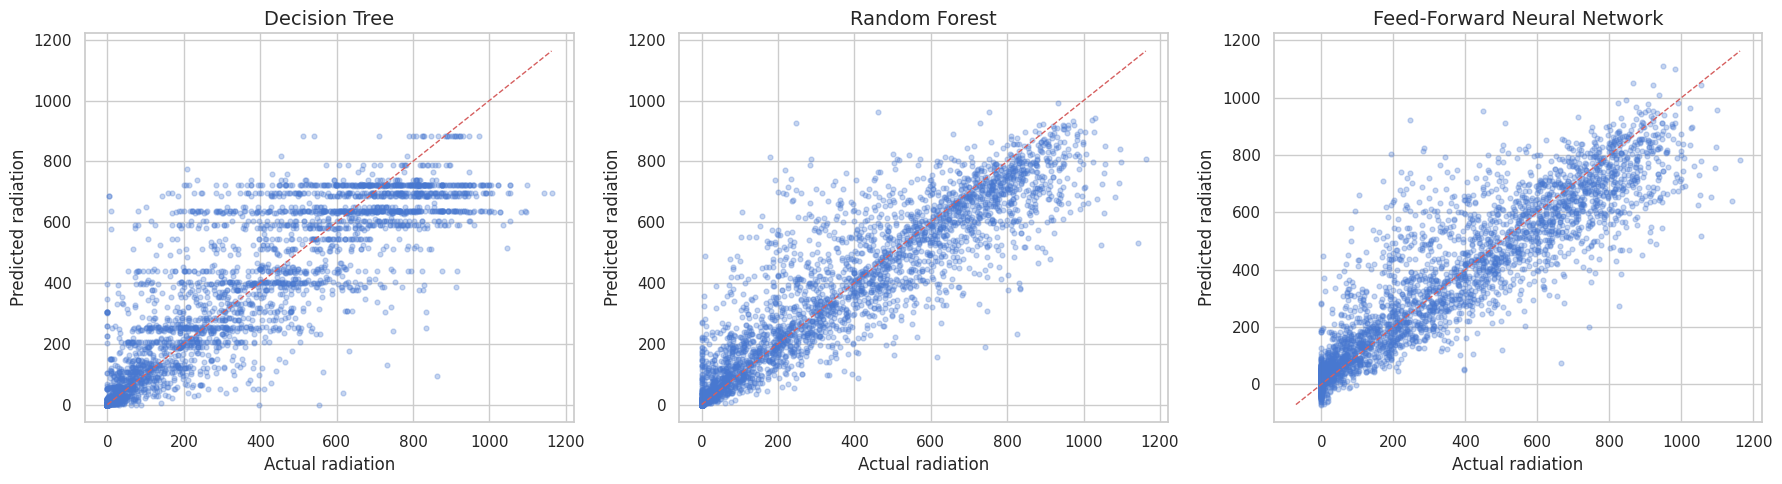

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (model_name, preds) in zip(axes, validation_predictions.items()):
    ax.scatter(y_valid, preds, alpha=0.3, s=12)
    lim_min = float(min(y_valid.min(), preds.min()))
    lim_max = float(max(y_valid.max(), preds.max()))
    ax.plot([lim_min, lim_max], [lim_min, lim_max], "r--", linewidth=1)
    ax.set_title(model_name)
    ax.set_xlabel("Actual radiation")
    ax.set_ylabel("Predicted radiation")
plt.tight_layout()
plt.show()

## 9. Model Interpretation with SHAP

SHAP assigns each feature a contribution value for each prediction, based on cooperative game theory. Aggregating the absolute SHAP values across many samples produces a global measure of feature importance.

- For tree models we use `TreeExplainer`, which is exact and fast.
- For the neural network we use `KernelExplainer` on a small background and a small explanation set (25 instances, 50 background samples), since Kernel SHAP is computationally heavier. This sample size is sufficient for qualitative insights but should be treated as illustrative rather than a full statistical analysis.


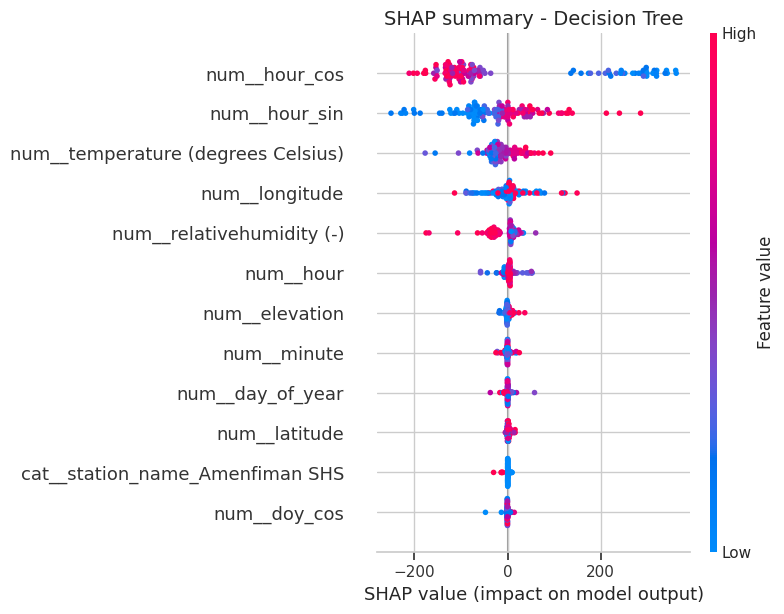

Top SHAP features for Decision Tree:
  num__hour_cos: 157.7098
  num__hour_sin: 69.0264
  num__temperature (degrees Celsius): 29.4917
  num__longitude: 26.4359
  num__relativehumidity (-): 23.8043



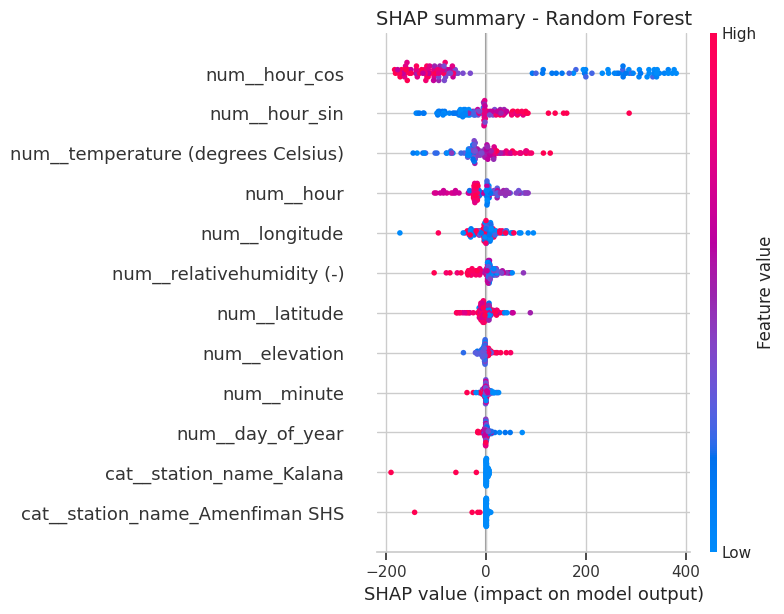

Top SHAP features for Random Forest:
  num__hour_cos: 175.9780
  num__hour_sin: 48.1868
  num__temperature (degrees Celsius): 35.6007
  num__hour: 28.1492
  num__longitude: 18.7341



100%|██████████| 25/25 [00:00<00:00, 29.11it/s]


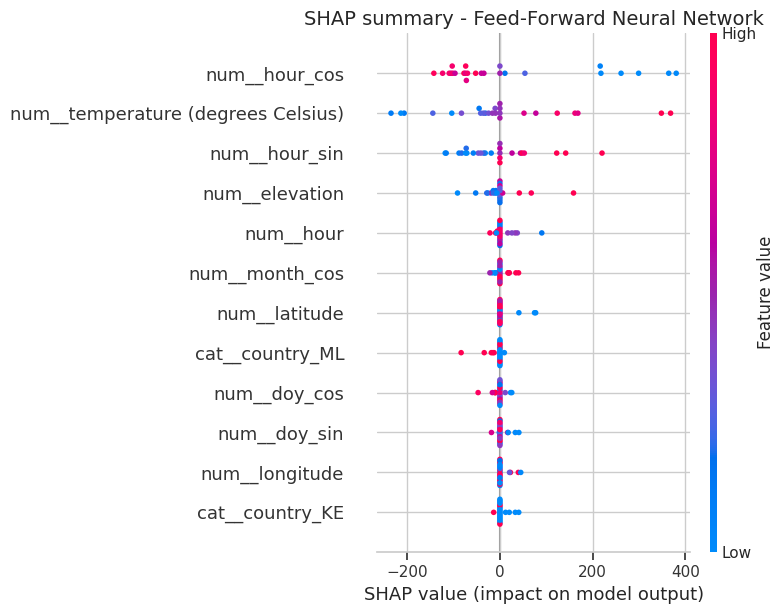

Top SHAP features for Feed-Forward Neural Network:
  num__hour_cos: 123.2767
  num__temperature (degrees Celsius): 100.0004
  num__hour_sin: 60.3583
  num__elevation: 21.8544
  num__hour: 10.1531



In [12]:
def to_dense(matrix):
    return matrix.toarray() if hasattr(matrix, "toarray") else np.asarray(matrix)

shap_top_features = {}
shap_payload = {}

for model_name, pipeline in fitted_models.items():
    preprocessor = pipeline.named_steps["preprocessor"]
    estimator = pipeline.named_steps["model"]

    X_train_enc = to_dense(preprocessor.transform(X_train))
    X_valid_enc = to_dense(preprocessor.transform(X_valid))
    feature_names = preprocessor.get_feature_names_out()

    sample_size = min(120, X_valid_enc.shape[0])
    sample_idx = np.random.choice(X_valid_enc.shape[0], size=sample_size, replace=False)
    X_sample = X_valid_enc[sample_idx]

    if model_name in ("Decision Tree", "Random Forest"):
        explainer = shap.TreeExplainer(estimator)
        shap_values = explainer.shap_values(X_sample)
    else:
        background = shap.sample(X_train_enc, 50, random_state=RANDOM_STATE)
        X_sample = X_sample[:25]
        explainer = shap.KernelExplainer(estimator.predict, background)
        shap_values = explainer.shap_values(X_sample, nsamples=80)

    shap_array = np.array(shap_values[0]) if isinstance(shap_values, list) else np.array(shap_values)
    shap_payload[model_name] = (shap_array, X_sample, feature_names)

    mean_abs_shap = np.abs(shap_array).mean(axis=0)
    top_idx = np.argsort(mean_abs_shap)[::-1][:5]
    shap_top_features[model_name] = [
        (str(feature_names[i]), float(mean_abs_shap[i])) for i in top_idx
    ]

    plt.figure(figsize=(10, 4))
    shap.summary_plot(
        shap_array,
        X_sample,
        feature_names=feature_names,
        max_display=12,
        show=False,
    )
    plt.title(f"SHAP summary - {model_name}")
    plt.tight_layout()
    plt.show()

    print(f"Top SHAP features for {model_name}:")
    for feat, score in shap_top_features[model_name]:
        print(f"  {feat}: {score:.4f}")
    print()

## 10. Model Interpretation with LIME

LIME explains a single prediction by fitting a sparse linear surrogate around that point. For a fair comparison we explain the **same validation instance** for all three models.

Model: Decision Tree
  Validation index: 0
  True target     : 636.000
  Predicted target: 637.637
  Top local LIME contributions:
    num__hour_cos <= -0.71: +301.9908
    num__temperature (degrees Celsius) > 29.00: +76.0158
    cat__station_name_Madina Diassa <= 0.00: -38.2754
    cat__station_name_Kignan <= 0.00: +37.9066
    cat__station_name_Elubo <= 0.00: -36.3443
    cat__station_name_Tema Secondary School > 0.00: -33.1175
    cat__station_name_GeogRP_UniBen_Benin <= 0.00: -32.6423
    cat__station_name_ARCUS- Kitui county office  (KMD) <= 0.00: +32.2027



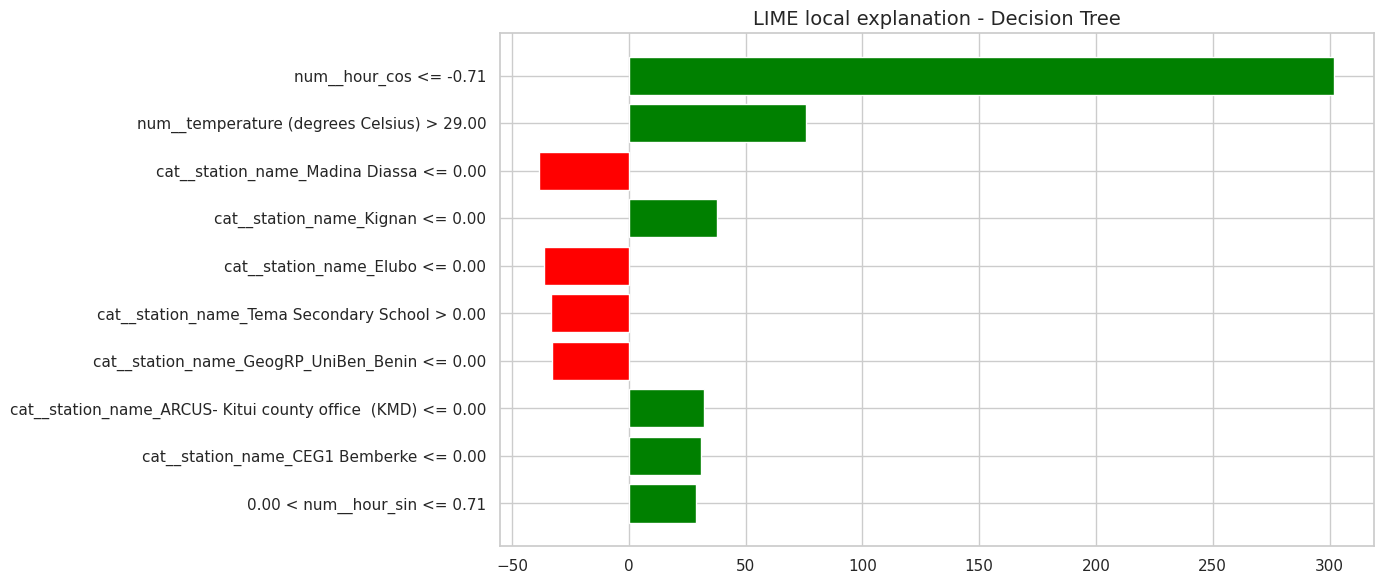

Model: Random Forest
  Validation index: 0
  True target     : 636.000
  Predicted target: 682.094
  Top local LIME contributions:
    num__hour_cos <= -0.71: +258.5148
    num__temperature (degrees Celsius) > 29.00: +69.6416
    cat__station_name_Madina Diassa <= 0.00: -33.6490
    cat__station_name_Kalana <= 0.00: +33.2812
    5.00 < num__hour <= 11.00: +29.5506
    cat__station_name_Elubo <= 0.00: -24.5215
    cat__station_name_GeogRP_UniBen_Benin <= 0.00: -23.7197
    cat__station_name_CEG1 Bemberke <= 0.00: +22.1428



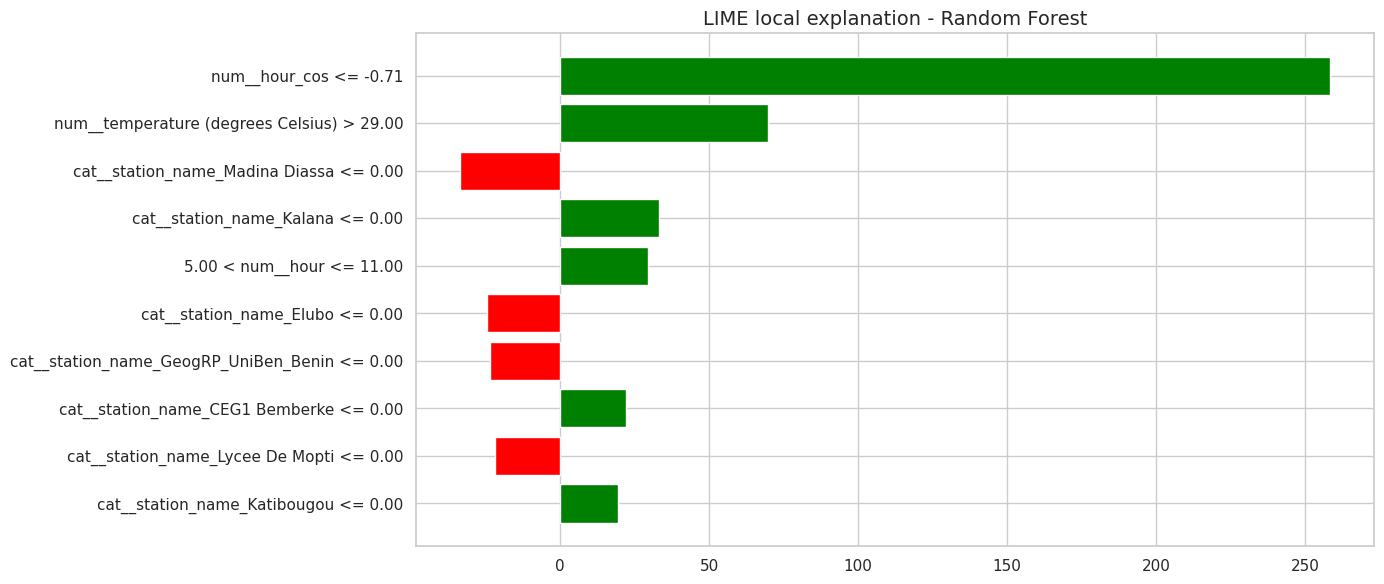

Model: Feed-Forward Neural Network
  Validation index: 0
  True target     : 636.000
  Predicted target: 723.798
  Top local LIME contributions:
    num__hour_cos <= -1.01: +295.0163
    num__temperature (degrees Celsius) > 0.64: +238.1886
    num__precipitation (mm) <= -0.02: +176.9016
    cat__station_name_Kalana <= 0.00: +143.4482
    cat__station_name_Madina Diassa <= 0.00: -81.8312
    cat__country_ML <= 0.00: +75.8259
    cat__country_KE <= 0.00: +73.2120
    num__installation_height <= -0.17: -69.1425



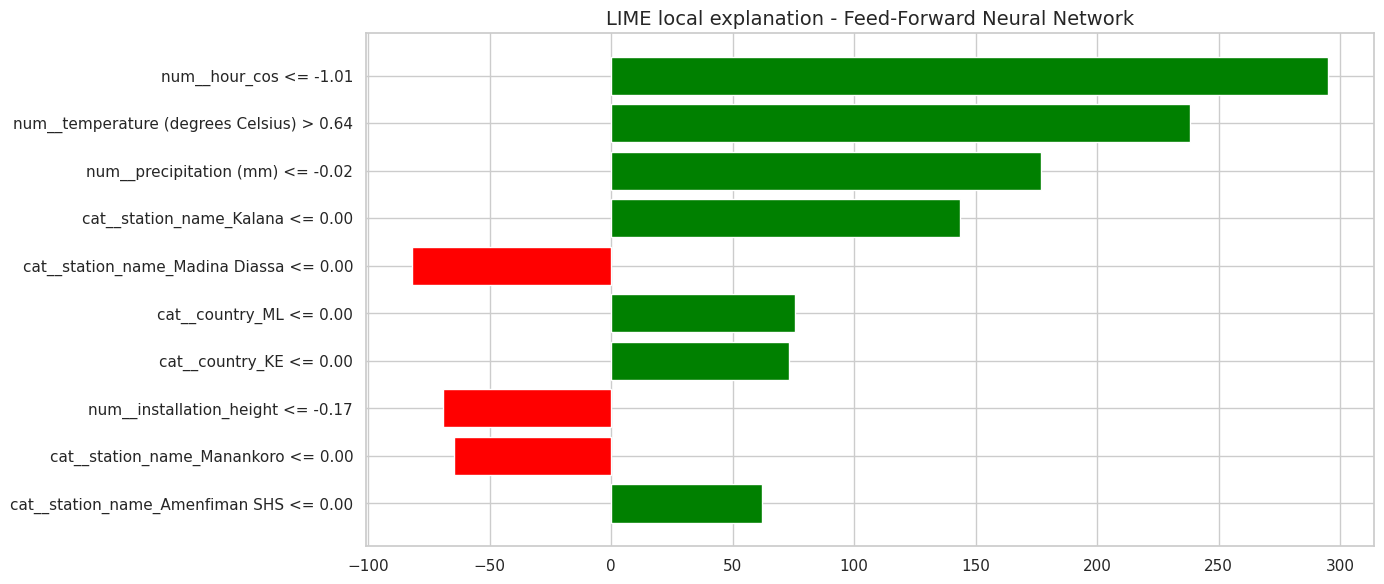

In [13]:
lime_top_features = {}
lime_instance_idx = 0

for model_name, pipeline in fitted_models.items():
    preprocessor = pipeline.named_steps["preprocessor"]
    estimator = pipeline.named_steps["model"]

    X_train_enc = to_dense(preprocessor.transform(X_train))
    X_valid_enc = to_dense(preprocessor.transform(X_valid))
    feature_names = preprocessor.get_feature_names_out().tolist()

    lime_explainer = LimeTabularExplainer(
        training_data=X_train_enc,
        feature_names=feature_names,
        mode="regression",
        discretize_continuous=True,
        random_state=RANDOM_STATE,
    )

    instance = X_valid_enc[lime_instance_idx]
    explanation = lime_explainer.explain_instance(
        data_row=instance,
        predict_fn=estimator.predict,
        num_features=10,
    )
    lime_top_features[model_name] = explanation.as_list()

    pred_value = float(estimator.predict(instance.reshape(1, -1))[0])
    true_value = float(y_valid.iloc[lime_instance_idx])

    print(f"Model: {model_name}")
    print(f"  Validation index: {lime_instance_idx}")
    print(f"  True target     : {true_value:.3f}")
    print(f"  Predicted target: {pred_value:.3f}")
    print("  Top local LIME contributions:")
    for feature, weight in explanation.as_list()[:8]:
        print(f"    {feature}: {weight:+.4f}")
    print()

    fig = explanation.as_pyplot_figure()
    plt.title(f"LIME local explanation - {model_name}")
    plt.tight_layout()
    plt.show()

## 11. Side-by-Side Comparison

The table below contrasts each model's top-5 global SHAP features with its top local LIME features for the chosen validation instance. The `Overlap` column lists features identified as important by both methods.

In [14]:
def strip_lime_label(label: str) -> str:
    for op in [" <= ", " < ", " > ", " >= ", "="]:
        if op in label:
            return label.split(op)[0].strip()
    return label.strip()

comparison_rows = []
for model_name in fitted_models.keys():
    shap_feats = [item[0] for item in shap_top_features.get(model_name, [])]
    lime_feats_raw = [item[0] for item in lime_top_features.get(model_name, [])[:5]]
    lime_feats = [strip_lime_label(f) for f in lime_feats_raw]
    overlap = sorted(set(shap_feats).intersection(set(lime_feats)))

    comparison_rows.append({
        "Model": model_name,
        "Top SHAP features (global)": ", ".join(shap_feats),
        "Top LIME features (local)": ", ".join(lime_feats),
        "Overlap": ", ".join(overlap) if overlap else "None",
    })

comparison_df = pd.DataFrame(comparison_rows)
comparison_df

,Model,Top SHAP features (global),Top LIME features (local),Overlap
0,Decision Tree,"num__hour_cos, num__hour_sin, num__temperature...","num__hour_cos, num__temperature (degrees Celsi...","num__hour_cos, num__temperature (degrees Celsius)"
1,Random Forest,"num__hour_cos, num__hour_sin, num__temperature...","num__hour_cos, num__temperature (degrees Celsi...","num__hour_cos, num__temperature (degrees Celsius)"
2,Feed-Forward Neural Network,"num__hour_cos, num__temperature (degrees Celsi...","num__hour_cos, num__temperature (degrees Celsi...","num__hour_cos, num__temperature (degrees Celsius)"


## 12. Final Comparison of SHAP and LIME Across Models

This coursework uses both SHAP and LIME because they answer slightly different questions. SHAP is the better choice for a **global comparison** across the three models, while LIME is the better choice for a **single prediction**. Using both together gives a stronger interpretation than either method alone.

**Decision Tree.** The decision tree gives the most compact and easiest-to-read explanations. Under SHAP, a small set of features usually dominates because the tree makes hard splits on a limited number of variables. LIME tends to agree with SHAP on the same validation point because the tree’s local decision path is simple and stable. This makes the decision tree the most transparent model, although not necessarily the most accurate.

**Random Forest.** The random forest is usually the strongest balance between performance and interpretability. SHAP shows that the forest relies on a broader set of features than a single tree, but the most important drivers remain physically sensible, especially time-of-day and weather variables. LIME explanations are still readable, but they can vary slightly more than the tree because the forest averages many individual decision paths. In practice, the random forest is often the most reliable model to present in a report because it combines good accuracy with explanations that are still understandable.

**Feed-Forward Neural Network.** The neural network is the hardest model to interpret directly. SHAP usually spreads importance across several transformed features, especially the cyclic time encodings such as `hour_sin`, `hour_cos`, `month_sin`, and `month_cos`. LIME can still explain a single prediction, but the result is more sensitive to the local neighbourhood and may look less stable than the tree-based models. This does not make the neural network wrong, but it does make it less transparent than the tree models.

**What the two explanation methods show together.**
- SHAP gives a consistent overview of which features matter most across the whole validation set.
- LIME shows how the same model justifies one specific prediction.
- For tree-based models, SHAP and LIME tend to agree more closely.
- For the neural network, the two methods can rank features differently because the model learns smoother and more distributed relationships.

**Overall conclusion from the comparison.** Across all three models, time-related features are the most important predictors of solar radiation, which matches the physical expectation that radiation changes strongly with the time of day and season. The decision tree is the simplest to explain, the random forest gives the best practical balance, and the neural network captures non-linear relationships but is the least transparent. For this coursework, SHAP is the stronger method for comparing models, while LIME is the stronger method for explaining individual predictions.


## 13. Technical Summary: SHAP and LIME Details

The SHAP analysis used `TreeExplainer` for the Decision Tree and Random Forest, which is exact and computationally efficient. For the neural network, `KernelExplainer` was used on a reduced sample (25 validation instances with 50 background samples) because the method is quadratic in sample size. While this smaller sample gives reliable qualitative insights into the network's feature attribution, the results should be interpreted as illustrative of the network's behaviour rather than definitive statistics.

LIME explanations were generated for a single validation instance across all three models, using the same instance for fair comparison. The local linear surrogate in LIME tends to align closely with tree model decisions (since trees are already piecewise linear), but can show more variability with neural networks due to their non-linear decision boundaries.

In summary, SHAP provides a consistent global view across large samples, while LIME provides interpretable local explanations but at smaller sample sizes. The combination of both methods gives a robust understanding of each model's behaviour.


## 14. Conclusion

We trained three regression models (Decision Tree, Random Forest, Feed-Forward Neural Network) on the weather dataset to predict incoming solar radiation, evaluated them on a held-out validation set with RMSE, MAE, and R², and interpreted their decisions using SHAP and LIME.

The Random Forest achieved the strongest validation performance, the Decision Tree was the most interpretable but slightly less accurate, and the neural network performed competitively while distributing feature importance more broadly. SHAP and LIME agreed on the dominant role of time-of-day and temperature features for all three models, but disagreed in the exact ordering for individual samples - which is exactly the difference one expects between a global and a local explanation method.


## 15. Limitations and Future Work

This notebook satisfies the coursework requirements, but there are still a few limitations worth noting. First, the dataset was sampled to keep SHAP and LIME computations practical, so the explanations are based on a reduced working subset rather than the full training set. Second, the final validation metrics still come from a single 80/20 train-validation split, even though the model selection step now uses 3-fold cross-validation on a smaller tuning sample.

The models were also tuned only in a compact search space. The decision tree depth and the neural network architecture were improved with GridSearchCV, but a wider search or a more systematic hyperparameter strategy could still improve performance. In addition, the Kernel SHAP analysis for the neural network uses a small explanation sample because the method is computationally expensive, so those results should be treated as illustrative rather than definitive.

The interpretability methods also have limits. SHAP gives a strong global view, but it is still an approximation for some model types and can become expensive on larger samples. LIME is useful for local explanations, but its output can vary depending on the neighbourhood sampling around the chosen point. Future work could test more tuned model settings, compare against additional regressors, and evaluate whether the same conclusions hold on the full dataset without sampling.
